# One training step of a GCN, by hand

**A glass-box companion to** `core-concepts.ipynb` and `replication.ipynb`
(Deshmukh, *Bot Detection in Social Media using GraphSage and BERT*, SJSU 2025).

`core-concepts.ipynb` compares two architectures on 8 nodes. This notebook zooms
in much further: **3 nodes, 2 features, one weight matrix, and exactly one
training cycle** — forward pass, loss, backward pass, optimiser step, verify.

Nothing is hidden inside a `nn.Module`. Every matrix is printed with its shape
and its actual decimals, and the numbers are chosen so you can check them on a
calculator. Where PyTorch does something for us (autograd, softmax,
cross-entropy) we **recompute it by hand and assert the two agree** — that is
the whole point of the notebook.

### Running it

Kernel: `botsage-venv` (the `.venv` beside this file). Register it once with:

```bash
01-info-propagation/bot-detection-paper/.venv/bin/python -m ipykernel install \
    --user --name botsage-venv --display-name "Python (bot-detection-paper)"
```

Only `torch`, `numpy` and `matplotlib` are needed. No data files, no GPU. This
notebook is a build artefact of `scripts/build_one_step_notebook.py` — edit the
builder, not the `.ipynb`.

---

## The micro-graph

Three accounts in a chain, **0 — 1 — 2**:

| Node | Role | Label $y$ | `activity_score` | `spam_score` |
|---|---|---|---|---|
| 0 | Human | 0 | 1 | 0 |
| 1 | **Bot** | **1** | 6 | 6 |
| 2 | Human | 0 | 3 | 1 |

The bot sits in the **middle**: both humans interact with it, and it interacts
with both of them. That placement is deliberate and it will produce a genuinely
surprising number in the very next cell.

Two matrices define the problem:

- $X \in \mathbb{R}^{3\times 2}$ — one row per node, one column per feature.
- $A \in \mathbb{R}^{3\times 3}$ — symmetric, $A_{uv}=1$ iff $u$ and $v$ are
  connected. A chain, so only $(0,1)$ and $(1,2)$ are set.

The model we are going to train for one step is:

$$\text{logits} = \underbrace{\mathrm{ReLU}\big(\underbrace{D^{-1}\hat{A}X}_{\text{aggregate}}\;W\big)}_{\text{GCN layer}}\;U$$

with $W \in \mathbb{R}^{2\times 2}$ (the GCN weights) and $U \in \mathbb{R}^{2\times 2}$
(the classification head). Twelve numbers in total — eight of them trainable.

In [1]:
import numpy as np
import torch
import torch.nn.functional as Fnn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_printoptions(precision=4, sci_mode=False, linewidth=100)

# --- Feature matrix ---------------------------------------------------------
# columns: [activity_score, spam_score]
X = torch.tensor([[1., 0.],     # node 0  Human : quiet, no spam
                  [6., 6.],     # node 1  BOT   : hyperactive AND spammy
                  [3., 1.]],    # node 2  Human : moderately active
                 dtype=torch.float32)

print("--- Feature Matrix (X) ---")
print(X)
print(f"shape: {tuple(X.shape)}  ->  (3 nodes, 2 features)\n")

# --- Adjacency matrix: the chain 0 - 1 - 2 ---------------------------------
A = torch.tensor([[0., 1., 0.],     # 0 is connected to 1
                  [1., 0., 1.],     # 1 is connected to 0 and 2
                  [0., 1., 0.]],    # 2 is connected to 1
                 dtype=torch.float32)

print("--- Adjacency Matrix (A) ---")
print(A)
print(f"shape: {tuple(A.shape)}  ->  (3 nodes, 3 nodes)")
print(f"symmetric (undirected): {torch.equal(A, A.T)}")
print(f"zero diagonal (no self-loops yet): {bool((A.diagonal() == 0).all())}\n")

# --- Labels -----------------------------------------------------------------
# 0 = Human, 1 = Bot.  CrossEntropyLoss wants class INDICES, hence dtype long.
y = torch.tensor([0, 1, 0], dtype=torch.long)

print("--- Labels (y) ---")
print(y, " -> [Human, Bot, Human]")
print(f"shape: {tuple(y.shape)}")

--- Feature Matrix (X) ---
tensor([[1., 0.],
        [6., 6.],
        [3., 1.]])
shape: (3, 2)  ->  (3 nodes, 2 features)

--- Adjacency Matrix (A) ---
tensor([[0., 1., 0.],
        [1., 0., 1.],
        [0., 1., 0.]])
shape: (3, 3)  ->  (3 nodes, 3 nodes)
symmetric (undirected): True
zero diagonal (no self-loops yet): True

--- Labels (y) ---
tensor([0, 1, 0])  -> [Human, Bot, Human]
shape: (3,)


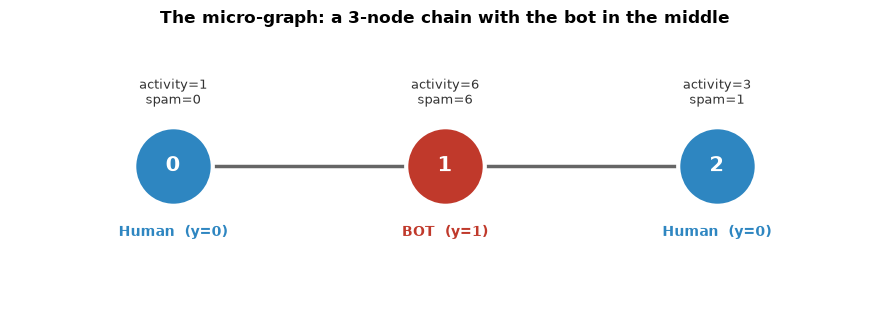

In [2]:
# --- Draw the micro-graph (pure matplotlib, no networkx) -------------------
pos = {0: (0.0, 0.0), 1: (1.0, 0.0), 2: (2.0, 0.0)}
colors = {0: "#2E86C1", 1: "#C0392B", 2: "#2E86C1"}   # blue human, red bot
names = {0: "Human", 1: "BOT", 2: "Human"}

fig, ax = plt.subplots(figsize=(9, 3.2))
for u, v in [(0, 1), (1, 2)]:
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color="#666666", lw=2.5, zorder=1)
for i in range(3):
    ax.scatter(*pos[i], s=3200, color=colors[i], edgecolors="white",
               linewidths=3, zorder=2)
    ax.text(pos[i][0], pos[i][1], f"{i}", color="white", fontsize=15,
            ha="center", va="center", fontweight="bold", zorder=3)
    ax.text(pos[i][0], pos[i][1] - 0.34, f"{names[i]}  (y={y[i].item()})",
            ha="center", fontsize=10, fontweight="bold", color=colors[i])
    ax.text(pos[i][0], pos[i][1] + 0.30,
            f"activity={X[i, 0]:.0f}\nspam={X[i, 1]:.0f}",
            ha="center", fontsize=9, color="#333333")

ax.set_xlim(-0.6, 2.6); ax.set_ylim(-0.65, 0.65)
ax.set_title("The micro-graph: a 3-node chain with the bot in the middle",
             fontsize=12, fontweight="bold")
ax.axis("off"); plt.tight_layout(); plt.show()

---

# CELL 2 · Forward pass, step 1 — graph convolution (neighbour averaging)

The convolution is three matrix operations and no parameters at all:

**1. Add self-loops.** Without them a node's own features would be *discarded* —
it would be described purely by its neighbours. So

$$\hat{A} = A + I$$

**2. Build the degree matrix.** $\hat{D}$ is diagonal with
$\hat{D}_{ii} = \sum_j \hat{A}_{ij}$, i.e. the number of nodes in $i$'s
neighbourhood *including itself*.

**3. Normalise and multiply.**

$$X_{\text{smooth}} = \hat{D}^{-1}\hat{A}X$$

Read this literally rather than as abstract algebra. $\hat{A}X$ **sums** each
node's own features with its neighbours'; $\hat{D}^{-1}$ then **divides by the
count**. So each row of $X_{\text{smooth}}$ is nothing more exotic than the
**arithmetic mean of a node's own feature vector and those of its neighbours.**

For our chain:

- Node 0 has neighbourhood $\{0, 1\}$ → mean of 2 rows → $\big[\tfrac{1+6}{2}, \tfrac{0+6}{2}\big] = [3.5,\; 3.0]$
- Node 1 has neighbourhood $\{0, 1, 2\}$ → mean of 3 rows
- Node 2 has neighbourhood $\{1, 2\}$ → mean of 2 rows

*(Kipf & Welling's paper uses the symmetric $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$
instead. The row-normalised $\hat{D}^{-1}\hat{A}$ used here is the exact mean,
which is what makes it followable by hand. Everything downstream is identical.)*

In [3]:
I3 = torch.eye(3)

# --- Step 1: self-loops -----------------------------------------------------
A_hat = A + I3
print("--- A_hat = A + I  (self-loops added) ---")
print(A_hat)
print("the new 1s on the diagonal are each node keeping its OWN features\n")

# --- Step 2: degree vector and its inverse ---------------------------------
deg = A_hat.sum(dim=1)                 # row sums = neighbourhood sizes
D_inv = torch.diag(1.0 / deg)

print("--- Degree vector (row sums of A_hat) ---")
print(deg, " -> node 0 sees 2 nodes, node 1 sees 3, node 2 sees 2\n")
print("--- D_inv = diag(1/deg) ---")
print(D_inv)
print("1/2 = 0.5000, 1/3 = 0.3333, 1/2 = 0.5000\n")

# --- Step 3: aggregate ------------------------------------------------------
X_smooth = D_inv @ A_hat @ X

print("--- X_smooth = D_inv @ A_hat @ X ---")
print(X_smooth)
print(f"shape: {tuple(X_smooth.shape)}  ->  unchanged, (3 nodes, 2 features)\n")

# --- Verify row 0 is literally an average ----------------------------------
manual_row0 = (X[0] + X[1]) / 2
print("Row 0 check, by hand:")
print(f"  node 0 features          : {X[0].tolist()}")
print(f"  node 1 features          : {X[1].tolist()}")
print(f"  their average            : ({X[0,0]:.0f}+{X[1,0]:.0f})/2 = {manual_row0[0]:.4f} , "
      f"({X[0,1]:.0f}+{X[1,1]:.0f})/2 = {manual_row0[1]:.4f}")
print(f"  X_smooth row 0           : {X_smooth[0].tolist()}")
print(f"  identical?               : {torch.allclose(manual_row0, X_smooth[0])}")

manual_row1 = (X[0] + X[1] + X[2]) / 3
print(f"\nRow 1 check (3 nodes): ({X[0,1]:.0f}+{X[1,1]:.0f}+{X[2,1]:.0f})/3 = "
      f"{manual_row1[1]:.4f}  vs X_smooth[1,1] = {X_smooth[1,1]:.4f}  "
      f"-> {torch.allclose(manual_row1, X_smooth[1])}")

--- A_hat = A + I  (self-loops added) ---
tensor([[1., 1., 0.],
        [1., 1., 1.],
        [0., 1., 1.]])
the new 1s on the diagonal are each node keeping its OWN features

--- Degree vector (row sums of A_hat) ---
tensor([2., 3., 2.])  -> node 0 sees 2 nodes, node 1 sees 3, node 2 sees 2

--- D_inv = diag(1/deg) ---
tensor([[0.5000, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000],
        [0.0000, 0.0000, 0.5000]])
1/2 = 0.5000, 1/3 = 0.3333, 1/2 = 0.5000

--- X_smooth = D_inv @ A_hat @ X ---
tensor([[3.5000, 3.0000],
        [3.3333, 2.3333],
        [4.5000, 3.5000]])
shape: (3, 2)  ->  unchanged, (3 nodes, 2 features)

Row 0 check, by hand:
  node 0 features          : [1.0, 0.0]
  node 1 features          : [6.0, 6.0]
  their average            : (1+6)/2 = 3.5000 , (0+6)/2 = 3.0000
  X_smooth row 0           : [3.5, 3.0]
  identical?               : True

Row 1 check (3 nodes): (0+6+1)/3 = 2.3333  vs X_smooth[1,1] = 2.3333  -> True


### Stop and look at the spam column

This is the number worth pausing on, and it is only visible because we printed
the decimals:

| Node | raw `spam_score` | **smoothed** `spam_score` |
|---|---|---|
| 0 (Human) | 0 | **3.00** |
| 1 (**Bot**) | **6** | **2.33** |
| 2 (Human) | 1 | **3.50** |

The bot had *by far* the highest raw spam score. After one round of averaging it
has the **lowest**. The ordering did not just weaken — it **inverted**.

Why: the bot's own value is averaged against *two* humans (weight $\tfrac13$
each), while each human averages against *one* bot (weight $\tfrac12$). A
high-degree node dilutes its own signal and donates it to its neighbours.

This is not a bug in our numbers — it is forced by the geometry. For the middle
node of a chain to keep the highest smoothed value you would need
$s_0 + s_2 > 2s_1$, i.e. the humans would have to be spammier than the bot.
**On this graph, no amount of training can separate the bot by spam magnitude.**

It is still linearly separable, though — just not by *level*. Look at the
**ratio** spam/activity: $3.0/3.5 = 0.857$, $2.33/3.33 = 0.700$, $3.5/4.5 = 0.778$.
The bot is the minimum, and geometrically its point lies off the line joining
the other two, so a line *can* isolate it. Separability survived; it just moved
from an obvious feature to a subtle one.

Two lessons that generalise well past this toy: **(1)** aggregation is smoothing,
and smoothing destroys extremes — which is precisely why stacking many GCN
layers causes *over-smoothing*; **(2)** you cannot diagnose a GNN from raw
features alone. You have to look at what the layer actually produced.

---

# CELL 3 · Forward pass, step 2 — the linear projection

Aggregation had no parameters: it can only mix, never re-weight. $W$ is where
learning lives.

$$H = X_{\text{smooth}}\,W, \qquad W \in \mathbb{R}^{2\times 2}$$

Think of $W$'s four entries as four sliders. Column $j$ of $W$ produces column
$j$ of $H$: it says *"to build hidden feature $j$, take this much smoothed
activity and this much smoothed spam."* Each output is a weighted recipe of the
inputs.

We set $W$ **by hand** rather than randomly, so the arithmetic is checkable:

$$W = \begin{bmatrix} 0.5 & -1.0 \\ 1.0 & 1.3 \end{bmatrix}
\qquad\begin{array}{l}\text{col 0: } 0.5\cdot\text{activity} + 1.0\cdot\text{spam}\\
\text{col 1: } -1.0\cdot\text{activity} + 1.3\cdot\text{spam}\end{array}$$

Column 1 has a **negative** weight on activity — it is a rough "spam relative to
activity" detector, and it is deliberately tuned so that one of the three
resulting numbers comes out negative. That matters for the next step.

`requires_grad=True` tells PyTorch: *record every operation touching this
tensor so I can differentiate through it later.* Without it, Cell 6 has nothing
to compute.

### Then ReLU

$$H_{\text{act}} = \mathrm{ReLU}(H) = \max(0, H)\quad\text{elementwise}$$

Without a non-linearity the whole network would collapse: $X_{\text{smooth}}WU$
is just $X_{\text{smooth}}(WU)$, one linear map, no matter how many layers you
stack. ReLU is the cheapest thing that breaks that collapse — it simply sets
negatives to zero. Watch **which** entry it zeroes; it comes back to bite in
Cell 6.

In [4]:
# --- The trainable GCN weight matrix ---------------------------------------
W = torch.tensor([[0.5, -1.0],
                  [1.0,  1.3]], dtype=torch.float32, requires_grad=True)

print("--- Weight Matrix (W) ---")
print(W.data)
print(f"shape: {tuple(W.shape)}  ->  (2 in-features, 2 out-features)")
print(f"requires_grad: {W.requires_grad}   <- PyTorch will now track it\n")

# --- Linear projection ------------------------------------------------------
H = X_smooth @ W
print("--- H = X_smooth @ W  (pre-activation) ---")
print(f"({X_smooth.shape[0]}x{X_smooth.shape[1]}) @ ({W.shape[0]}x{W.shape[1]}) "
      f"= ({H.shape[0]}x{H.shape[1]})")
print(H.data, "\n")

# Hand-check one entry so the matmul is not a black box.
h00 = X_smooth[0, 0] * W[0, 0] + X_smooth[0, 1] * W[1, 0]
print("H[0,0] by hand: X_smooth[0,0]*W[0,0] + X_smooth[0,1]*W[1,0]")
print(f"              = {X_smooth[0,0]:.4f}*{W[0,0].item():.1f} + "
      f"{X_smooth[0,1]:.4f}*{W[1,0].item():.1f} = {h00.item():.4f}"
      f"   (matches: {torch.allclose(h00, H[0,0])})")

h11 = X_smooth[1, 0] * W[0, 1] + X_smooth[1, 1] * W[1, 1]
print("H[1,1] by hand: X_smooth[1,0]*W[0,1] + X_smooth[1,1]*W[1,1]")
print(f"              = {X_smooth[1,0]:.4f}*{W[0,1].item():.1f} + "
      f"{X_smooth[1,1]:.4f}*{W[1,1].item():.1f} = {h11.item():.4f}"
      f"   <-- NEGATIVE\n")

# --- ReLU -------------------------------------------------------------------
H_act = torch.relu(H)
print("--- H_act = ReLU(H) = max(0, H) ---")
print(H_act.data)
print(f"shape: {tuple(H_act.shape)}  ->  unchanged; ReLU is elementwise\n")

clamped = (H < 0)
print(f"entries clamped to zero: {int(clamped.sum())} of {H.numel()}")
for i, j in zip(*torch.where(clamped)):
    print(f"  H[{i},{j}] = {H[i,j].item():+.4f}  ->  0.0000   "
          f"(node {i}, which is the {'BOT' if i == 1 else 'Human'})")
print("\nRemember this: the ONE clamped entry belongs to node 1, the bot.")

--- Weight Matrix (W) ---
tensor([[ 0.5000, -1.0000],
        [ 1.0000,  1.3000]])
shape: (2, 2)  ->  (2 in-features, 2 out-features)
requires_grad: True   <- PyTorch will now track it

--- H = X_smooth @ W  (pre-activation) ---
(3x2) @ (2x2) = (3x2)
tensor([[ 4.7500,  0.4000],
        [ 4.0000, -0.3000],
        [ 5.7500,  0.0500]]) 

H[0,0] by hand: X_smooth[0,0]*W[0,0] + X_smooth[0,1]*W[1,0]
              = 3.5000*0.5 + 3.0000*1.0 = 4.7500   (matches: True)
H[1,1] by hand: X_smooth[1,0]*W[0,1] + X_smooth[1,1]*W[1,1]
              = 3.3333*-1.0 + 2.3333*1.3 = -0.3000   <-- NEGATIVE

--- H_act = ReLU(H) = max(0, H) ---
tensor([[4.7500, 0.4000],
        [4.0000, 0.0000],
        [5.7500, 0.0500]])
shape: (3, 2)  ->  unchanged; ReLU is elementwise

entries clamped to zero: 1 of 6
  H[1,1] = -0.3000  ->  0.0000   (node 1, which is the BOT)

Remember this: the ONE clamped entry belongs to node 1, the bot.


---

# CELL 4 · Forward pass, step 3 — logits and softmax

$H_{\text{act}}$ holds two abstract hidden numbers per node. We need two
**class scores** per node, so we apply a second matrix — the classification
head $U$ — with one column per class:

$$Z = H_{\text{act}}\,U, \qquad U \in \mathbb{R}^{2\times 2},\qquad
Z_{i0} = \text{score(Human)},\; Z_{i1} = \text{score(Bot)}$$

These raw scores are the **logits**. They are unbounded and live on no
meaningful scale — $Z_{i0} > Z_{i1}$ simply means "Human wins".

To turn them into probabilities we use **softmax**, which we will compute in
three explicit steps rather than calling the built-in:

$$p_{ic} = \frac{e^{Z_{ic}}}{\sum_{k} e^{Z_{ik}}}$$

1. **Exponentiate** — makes everything positive and amplifies differences.
2. **Sum** across the classes of each node.
3. **Divide** — now each row sums to exactly 1.

One practical note we will demonstrate: implementations subtract
$\max_k Z_{ik}$ from every logit first. This changes nothing mathematically (the
constant cancels top and bottom) but prevents $e^{Z}$ from overflowing to `inf`.
It is the single most common source of `NaN` in hand-rolled classifiers.

In [5]:
# --- Classification head ----------------------------------------------------
# Column 0 scores "Human", column 1 scores "Bot". Also set by hand.
U = torch.tensor([[ 1.0, -1.0],
                  [-1.0,  2.0]], dtype=torch.float32, requires_grad=True)

print("--- Classification head (U) ---")
print(U.data)
print(f"shape: {tuple(U.shape)}  ->  (2 hidden dims, 2 classes)\n")

# --- Logits -----------------------------------------------------------------
Z = H_act @ U
print("--- Logits Z = H_act @ U ---")
print(f"({H_act.shape[0]}x{H_act.shape[1]}) @ ({U.shape[0]}x{U.shape[1]}) "
      f"= ({Z.shape[0]}x{Z.shape[1]})   columns = [score_Human, score_Bot]")
print(Z.data, "\n")

z00 = H_act[0, 0] * U[0, 0] + H_act[0, 1] * U[1, 0]
print(f"Z[0,0] by hand = {H_act[0,0]:.4f}*{U[0,0].item():.1f} + "
      f"{H_act[0,1]:.4f}*{U[1,0].item():.1f} = {z00.item():.4f}"
      f"  (matches: {torch.allclose(z00, Z[0,0])})\n")

# --- Softmax, step by step --------------------------------------------------
Z_shift = Z - Z.max(dim=1, keepdim=True).values     # numerical-stability shift
exp_Z = torch.exp(Z_shift)
sum_exp = exp_Z.sum(dim=1, keepdim=True)
probs = exp_Z / sum_exp

print("--- Softmax in three steps ---")
print("1. shifted logits (Z - rowmax), for numerical stability:")
print(Z_shift.data)
print("2. exp(shifted):")
print(exp_Z.data)
print("3. row sums:")
print(sum_exp.data.squeeze())
print("4. probabilities = exp / rowsum:")
print(probs.data)
print(f"\nevery row sums to 1: {torch.allclose(probs.sum(1), torch.ones(3))}")
print(f"agrees with torch.softmax: {torch.allclose(probs, torch.softmax(Z, dim=1))}\n")

# --- Side-by-side summary ---------------------------------------------------
print("=" * 74)
print(f"{'node':<6}{'truth':<9}{'logit_H':>10}{'logit_B':>10}"
      f"{'P(Human)':>11}{'P(Bot)':>10}{'predicted':>12}")
print("-" * 74)
for i in range(3):
    pred = int(Z[i].argmax())
    truth = int(y[i])
    mark = "OK" if pred == truth else "WRONG"
    print(f"{i:<6}{['Human','Bot'][truth]:<9}{Z[i,0].item():>10.4f}"
          f"{Z[i,1].item():>10.4f}{probs[i,0].item():>11.4f}"
          f"{probs[i,1].item():>10.4f}{['Human','Bot'][pred]:>9} {mark}")
print("=" * 74)
print("\nThe model calls the BOT a Human with probability "
      f"{probs[1,0].item():.4f} -- it is not merely wrong, it is confidently")
print("wrong. Confident errors produce large gradients, as Cell 5 will show.")

--- Classification head (U) ---
tensor([[ 1., -1.],
        [-1.,  2.]])
shape: (2, 2)  ->  (2 hidden dims, 2 classes)

--- Logits Z = H_act @ U ---
(3x2) @ (2x2) = (3x2)   columns = [score_Human, score_Bot]
tensor([[ 4.3500, -3.9500],
        [ 4.0000, -4.0000],
        [ 5.7000, -5.6500]]) 

Z[0,0] by hand = 4.7500*1.0 + 0.4000*-1.0 = 4.3500  (matches: True)

--- Softmax in three steps ---
1. shifted logits (Z - rowmax), for numerical stability:
tensor([[  0.0000,  -8.3000],
        [  0.0000,  -8.0000],
        [  0.0000, -11.3500]])
2. exp(shifted):
tensor([[1.0000, 0.0002],
        [1.0000, 0.0003],
        [1.0000, 0.0000]])
3. row sums:
tensor([1.0002, 1.0003, 1.0000])
4. probabilities = exp / rowsum:
tensor([[0.9998, 0.0002],
        [0.9997, 0.0003],
        [1.0000, 0.0000]])

every row sums to 1: True
agrees with torch.softmax: True

node  truth       logit_H   logit_B   P(Human)    P(Bot)   predicted
--------------------------------------------------------------------------

---

# CELL 5 · Step 4 — the loss

The loss turns "how wrong are we" into **one number** we can differentiate.
Cross-entropy for a single node $i$ with true class $c_i$ is:

$$\mathcal{L}_i = -\log p_{i,c_i}$$

That is the whole formula — it looks *only* at the probability assigned to the
correct class and ignores the rest. Its shape is what makes it work:

| $p_{\text{correct}}$ | $-\log p$ | reading |
|---|---|---|
| 1.00 | 0.00 | perfect, no penalty |
| 0.50 | 0.69 | a coin flip |
| 0.10 | 2.30 | poor |
| 0.0003 | **8.00** | confidently wrong — punished brutally |

As $p \to 0$ the loss $\to \infty$. Being *confidently* wrong costs far more
than being *uncertainly* wrong, which is exactly the incentive we want.

**For node 1 (the bot):** the model assigned $P(\text{Bot}) \approx 0.000335$,
so $\mathcal{L}_1 = -\log(0.000335) \approx 8.0$.

The total is the mean over nodes:

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N}\mathcal{L}_i$$

A note on the API, since it trips people up constantly: **`nn.CrossEntropyLoss`
takes raw logits, not probabilities.** It applies `log_softmax` internally. Feed
it softmax output and you will silently apply softmax twice, flattening your
gradients — the model still "trains", just badly. We verify below that
PyTorch's number matches our hand-computed $-\log p$.

In [6]:
# --- Per-node loss ----------------------------------------------------------
# reduction='none' keeps the three losses separate. NOTE: Z, not probs.
per_node_loss = Fnn.cross_entropy(Z, y, reduction="none")

print("--- Per-node cross-entropy ---")
for i in range(3):
    p_correct = probs[i, y[i]].item()
    manual = -np.log(p_correct)
    role = "BOT  " if y[i] == 1 else "Human"
    print(f"Node {i} ({role}) Loss: {per_node_loss[i].item():>9.6f}"
          f"   |  P(correct class) = {p_correct:.6f}"
          f"   |  -log(p) by hand = {manual:>9.6f}")

manual_all = -torch.log(probs.gather(1, y.view(-1, 1)).squeeze())
print(f"\nhand-computed -log(p) matches PyTorch: "
      f"{torch.allclose(manual_all, per_node_loss, atol=1e-5)}")

# --- Total ------------------------------------------------------------------
loss = per_node_loss.mean()
print("\n--- Total Epoch 1 Loss: ---")
print(f"    ({per_node_loss[0].item():.6f} + {per_node_loss[1].item():.6f} + "
      f"{per_node_loss[2].item():.6f}) / 3")
print(f"    = {loss.item():.6f}")
print(f"\nscalar? shape = {tuple(loss.shape)}  (a 0-dim tensor -- backward()")
print("needs exactly one number, which is why we average)\n")

share = per_node_loss / per_node_loss.sum() * 100
print("Where the loss comes from:")
for i in range(3):
    bar = "#" * max(1, int(share[i].item() / 2))
    print(f"  node {i}: {share[i].item():6.2f}%  {bar}")
print("\nThe bot accounts for essentially ALL of it. The two humans are already")
print("classified correctly with near-total confidence, so they contribute")
print("almost nothing and will barely influence the gradient.")

--- Per-node cross-entropy ---
Node 0 (Human) Loss:  0.000249   |  P(correct class) = 0.999752   |  -log(p) by hand =  0.000249
Node 1 (BOT  ) Loss:  8.000336   |  P(correct class) = 0.000335   |  -log(p) by hand =  8.000335
Node 2 (Human) Loss:  0.000012   |  P(correct class) = 0.999988   |  -log(p) by hand =  0.000012

hand-computed -log(p) matches PyTorch: True

--- Total Epoch 1 Loss: ---
    (0.000249 + 8.000336 + 0.000012) / 3
    = 2.666865

scalar? shape = ()  (a 0-dim tensor -- backward()
needs exactly one number, which is why we average)

Where the loss comes from:
  node 0:   0.00%  #
  node 1: 100.00%  #################################################
  node 2:   0.00%  #

The bot accounts for essentially ALL of it. The two humans are already
classified correctly with near-total confidence, so they contribute
almost nothing and will barely influence the gradient.


---

# CELL 6 · Step 5 — backpropagation

## What a gradient actually is

$\dfrac{\partial \mathcal{L}}{\partial W_{ij}}$ answers one concrete question:

> *If I nudge $W_{ij}$ up by a tiny amount $\epsilon$, how much does the total
> loss change?*

It is a **slope**, and its units are "loss per unit of weight". The sign is the
part you act on:

- **Positive** gradient → increasing that weight **increases** the loss → so we
  should **decrease** it.
- **Negative** gradient → increasing that weight **decreases** the loss → so we
  should **increase** it.

Either way: **move against the sign of the gradient.** That single rule is all
of gradient descent.

`loss.backward()` computes all eight partial derivatives (four in $W$, four in
$U$) in one backward sweep, using the chain rule over the graph of operations
PyTorch recorded during the forward pass. For our network the chain is:

$$\frac{\partial \mathcal{L}}{\partial W}
= X_{\text{smooth}}^{\top}\Big[\underbrace{\big(\tfrac{1}{N}(P - Y)\,U^{\top}\big)}_{\text{through the head}} \odot \underbrace{\mathbb{1}[H > 0]}_{\text{through ReLU}}\Big]$$

We will not take PyTorch's word for it. Below we recompute that expression by
hand with plain matrix multiplications, and separately estimate one entry by
**finite differences** — literally nudging the weight and re-running the forward
pass. All three must agree.

Note the $\mathbb{1}[H>0]$ term. ReLU's derivative is 1 where the input was
positive and **0 where it was negative**. A clamped entry does not just lose its
value in the forward pass; it **blocks the gradient** flowing back through it.
Watch what that does to column 1 of `W.grad`.

In [7]:
# --- The backward pass ------------------------------------------------------
loss.backward()

print("--- Weight Matrix W (unchanged by backward) ---")
print(W.data)
print("\n--- Gradient dLoss/dW  (W.grad) ---")
print(W.grad)
print(f"shape: {tuple(W.grad.shape)}  ->  identical to W: one slope per weight\n")

print("=" * 70)
print("Reading the gradient, entry by entry:")
for i in range(2):
    for j in range(2):
        g = W.grad[i, j].item()
        if abs(g) < 1e-3:
            verdict = "~ZERO: this weight barely affects the loss right now"
        elif g > 0:
            verdict = "POSITIVE: increasing this weight INCREASES the loss -> decrease it"
        else:
            verdict = "NEGATIVE: increasing this weight DECREASES the loss -> increase it"
        print(f"  W[{i},{j}] = {W.data[i,j].item():+.4f}  grad = {g:+.6f}")
        print(f"           -> {verdict}")
print("=" * 70)

--- Weight Matrix W (unchanged by backward) ---
tensor([[ 0.5000, -1.0000],
        [ 1.0000,  1.3000]])

--- Gradient dLoss/dW  (W.grad) ---
tensor([[2.2209, 0.0009],
        [1.5545, 0.0008]])
shape: (2, 2)  ->  identical to W: one slope per weight

Reading the gradient, entry by entry:
  W[0,0] = +0.5000  grad = +2.220862
           -> POSITIVE: increasing this weight INCREASES the loss -> decrease it
  W[0,1] = -1.0000  grad = +0.000923
           -> ~ZERO: this weight barely affects the loss right now
  W[1,0] = +1.0000  grad = +1.554509
           -> POSITIVE: increasing this weight INCREASES the loss -> decrease it
  W[1,1] = +1.3000  grad = +0.000787
           -> ~ZERO: this weight barely affects the loss right now


In [8]:
# --- Verification 1: recompute dL/dW by hand, no autograd ------------------
# Every line below is one link of the chain rule, written out.
N = 3
Y_onehot = torch.zeros(3, 2)
Y_onehot[range(3), y] = 1.0

dL_dZ    = (probs.detach() - Y_onehot) / N          # softmax + CE combined
dL_dHact = dL_dZ @ U.data.T                         # back through the head
relu_mask = (H.data > 0).float()                    # ReLU derivative: 1 or 0
dL_dH    = dL_dHact * relu_mask                     # back through ReLU
dL_dW    = X_smooth.T @ dL_dH                       # back through the matmul

print("dL/dZ  (probs - onehot)/N :\n", dL_dZ)
print("\nReLU mask 1[H > 0] :\n", relu_mask)
print("   ^ the 0 at position [1,1] is the clamped entry from Cell 3")
print("\ndL/dW computed by hand :\n", dL_dW)
print("dL/dW from autograd    :\n", W.grad)
assert torch.allclose(dL_dW, W.grad, atol=1e-6), "hand-derived gradient disagrees"
print("\n  PASS: hand-derived chain rule == autograd, to 1e-6")

# --- Verification 2: finite differences ------------------------------------
# The definition of a derivative, applied numerically: assumption-free, but it
# needs care. A central difference subtracts two nearly-identical numbers, so in
# float32 (~7 significant digits) the cancellation would leave us ~3 digits of
# signal. We therefore run this check in FLOAT64. Doing it in float32 "works"
# but agrees only to ~1e-3, which would be indistinguishable from a real bug.
Xs64, U64, W64 = X_smooth.double(), U.data.double(), W.data.double()

def forward_loss(W_test: torch.Tensor) -> float:
    '''Full forward pass with a given W (float64); returns the scalar loss.'''
    return Fnn.cross_entropy(torch.relu(Xs64 @ W_test) @ U64, y).item()

eps = 1e-6
print("\n--- Verification 2: central finite differences (float64) ---")
print(f"{'entry':<10}{'autograd':>14}{'(L(+e)-L(-e))/2e':>22}{'rel. error':>14}")
for i in range(2):
    for j in range(2):
        Wp, Wm = W64.clone(), W64.clone()
        Wp[i, j] += eps
        Wm[i, j] -= eps
        fd = (forward_loss(Wp) - forward_loss(Wm)) / (2 * eps)
        ag = W.grad[i, j].item()
        print(f"W[{i},{j}]{'':<5}{ag:>14.6f}{fd:>22.6f}{abs(fd-ag)/abs(ag):>14.2e}")
print('''
  The gradient is not magic: it is the slope you would measure by nudging the
  weight and re-running the forward pass.

  On the residuals -- the two large entries agree to ~4e-8, but the two
  near-zero ones only to ~6e-5. That gap is real and it is in AUTOGRAD's
  float32 value, not in the finite difference. Reason: dL/dZ contains
  (probs - onehot), and for nodes 0 and 2 that is 1 - 0.99975, which discards
  about four leading digits to cancellation. A float32 gradient built on top of
  that subtraction has only ~4 good digits left. Nothing is wrong -- but it is
  why gradient checks are conventionally run in float64.''')

dL/dZ  (probs - onehot)/N :
 tensor([[-0.0001,  0.0001],
        [ 0.3332, -0.3332],
        [-0.0000,  0.0000]])

ReLU mask 1[H > 0] :
 tensor([[1., 1.],
        [1., 0.],
        [1., 1.]])
   ^ the 0 at position [1,1] is the clamped entry from Cell 3

dL/dW computed by hand :
 tensor([[2.2209, 0.0009],
        [1.5545, 0.0008]])
dL/dW from autograd    :
 tensor([[2.2209, 0.0009],
        [1.5545, 0.0008]])

  PASS: hand-derived chain rule == autograd, to 1e-6

--- Verification 2: central finite differences (float64) ---
entry           autograd      (L(+e)-L(-e))/2e    rel. error
W[0,0]           2.220862              2.220862      3.66e-08
W[0,1]           0.000923              0.000923      6.09e-05
W[1,0]           1.554509              1.554509      4.76e-08
W[1,1]           0.000787              0.000787      5.62e-05

  The gradient is not magic: it is the slope you would measure by nudging the
  weight and re-running the forward pass.

  On the residuals -- the two large entr

In [9]:
# --- Why is column 1 of the gradient nearly zero? --------------------------
print("W.grad column 0 :", W.grad[:, 0].tolist())
print("W.grad column 1 :", W.grad[:, 1].tolist())
print(f"\ncolumn 1 is ~{(W.grad[:,0].abs().mean() / W.grad[:,1].abs().mean()):.0f}x"
      " smaller. That is not a rounding artefact -- here is the cause.\n")

print("Per-node contribution to dL/dW[:,1]  (= X_smooth[i] * dL_dH[i,1]):")
for i in range(3):
    contrib = X_smooth[i] * dL_dH[i, 1]
    gate = "OPEN " if relu_mask[i, 1] > 0 else "SHUT "
    role = "BOT  " if y[i] == 1 else "Human"
    print(f"  node {i} ({role}) ReLU gate {gate} | dL_dH[{i},1] = "
          f"{dL_dH[i,1].item():+.6f} | contributes {contrib.tolist()}")

print('''
Two facts collide here:

  1. Node 1 (the bot) carries ~100% of the loss, so it is the ONLY node with a
     meaningful error signal to send backwards.
  2. Node 1's ReLU gate in column 1 is SHUT -- its pre-activation was -0.3, so
     the derivative of ReLU there is exactly 0.

So the only node with something to say cannot say it through column 1, and the
only nodes whose gates are open have almost nothing to contribute. Column 1
therefore learns essentially nothing this step.

This is the 'dying ReLU' problem in miniature, and you can only see it by
printing the numbers. A unit that is clamped for the examples that matter is
invisible to the optimiser -- it receives no gradient, so it never moves, so it
stays clamped. Leaky ReLU exists precisely to keep that gate slightly ajar.''')

W.grad column 0 : [2.2208621501922607, 1.5545094013214111]
W.grad column 1 : [0.0009226106340065598, 0.0007866019150242209]

column 1 is ~2209x smaller. That is not a rounding artefact -- here is the cause.

Per-node contribution to dL/dW[:,1]  (= X_smooth[i] * dL_dH[i,1]):
  node 0 (Human) ReLU gate OPEN  | dL_dH[0,1] = +0.000248 | contributes [0.0008696349104866385, 0.0007454013684764504]
  node 1 (BOT  ) ReLU gate SHUT  | dL_dH[1,1] = -0.000000 | contributes [-0.0, -0.0]
  node 2 (Human) ReLU gate OPEN  | dL_dH[2,1] = +0.000012 | contributes [5.3010619012638927e-05, 4.123047983739525e-05]

Two facts collide here:

  1. Node 1 (the bot) carries ~100% of the loss, so it is the ONLY node with a
     meaningful error signal to send backwards.
  2. Node 1's ReLU gate in column 1 is SHUT -- its pre-activation was -0.3, so
     the derivative of ReLU there is exactly 0.

So the only node with something to say cannot say it through column 1, and the
only nodes whose gates are open have almo

---

# CELL 7 · Step 6 — the optimiser step

Plain gradient descent, in full:

$$W_{\text{new}} = W_{\text{old}} - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$

The **minus** sign is the whole algorithm: move *against* the slope. The
learning rate $\eta$ scales the move — a pure step-size choice, with the classic
trade-off:

- too small → the loss creeps down and training takes forever;
- too large → you overshoot the minimum and the loss can *increase* or diverge.

We use $\eta = 0.1$ and update **$W$ only**, holding the head $U$ fixed, so that
any change in the loss is attributable to $W$ alone. (A real optimiser updates
every parameter at once; `torch.optim.SGD` does exactly this line for each of
them.)

`with torch.no_grad():` is required. The update is bookkeeping, not part of the
model's computation — without it PyTorch would record the subtraction into the
autograd graph and try to differentiate through your optimiser.

In [10]:
lr = 0.1
W_old = W.data.clone()

with torch.no_grad():
    W_new = W - lr * W.grad          # the entire optimiser, one line

print(f"learning rate = {lr}\n")
print("--- The update, entry by entry ---")
print(f"{'entry':<9}{'W_old':>10}{'grad':>12}{'lr*grad':>12}{'W_new':>10}{'moved':>10}")
print("-" * 63)
for i in range(2):
    for j in range(2):
        g = W.grad[i, j].item()
        old, new = W_old[i, j].item(), W_new[i, j].item()
        print(f"W[{i},{j}]{'':<4}{old:>10.4f}{g:>12.6f}{lr*g:>12.6f}"
              f"{new:>10.4f}{new-old:>+10.4f}")
print("-" * 63)

print("\n--- W_old ---")
print(W_old)
print("\n--- W_new ---")
print(W_new)
print("\n--- displacement (W_new - W_old) ---")
print(W_new - W_old)
print("\nEvery gradient was positive, so every weight moved DOWN. Column 1")
print("barely moved at all -- its gradient was ~0.0009, so lr*grad ~ 0.00009.")

learning rate = 0.1

--- The update, entry by entry ---
entry         W_old        grad     lr*grad     W_new     moved
---------------------------------------------------------------
W[0,0]        0.5000    2.220862    0.222086    0.2779   -0.2221
W[0,1]       -1.0000    0.000923    0.000092   -1.0001   -0.0001
W[1,0]        1.0000    1.554509    0.155451    0.8445   -0.1555
W[1,1]        1.3000    0.000787    0.000079    1.2999   -0.0001
---------------------------------------------------------------

--- W_old ---
tensor([[ 0.5000, -1.0000],
        [ 1.0000,  1.3000]])

--- W_new ---
tensor([[ 0.2779, -1.0001],
        [ 0.8445,  1.2999]])

--- displacement (W_new - W_old) ---
tensor([[-0.2221, -0.0001],
        [-0.1555, -0.0001]])

Every gradient was positive, so every weight moved DOWN. Column 1
barely moved at all -- its gradient was ~0.0009, so lr*grad ~ 0.00009.


---

# CELL 8 · Step 7 — did we actually learn?

The claim implicit in every training loop is testable: if the gradient was
computed correctly and the step size is sane, then re-running the **identical**
forward pass with $W_{\text{new}}$ must produce a **lower** loss.

So we do exactly that — same $X$, same $A$, same $U$, same labels, one thing
changed — and compare. Note this is a *local* guarantee only: the gradient
describes the slope at the point we measured it, so it promises improvement for
a sufficiently small $\eta$, not for any $\eta$. We check $\eta = 0.1$ empirically
and then sweep a range to see where the promise breaks down.

In [11]:
# --- Identical forward pass, new W -----------------------------------------
with torch.no_grad():
    X_smooth_2 = D_inv @ A_hat @ X          # unchanged: no parameters here
    H_2 = X_smooth_2 @ W_new
    H_act_2 = torch.relu(H_2)
    Z_2 = H_act_2 @ U.data
    probs_2 = torch.softmax(Z_2, dim=1)
    per_node_loss_2 = Fnn.cross_entropy(Z_2, y, reduction="none")
    loss_2 = per_node_loss_2.mean()

print("--- Forward pass 2 (W_new) ---")
print("H_2:\n", H_2)
print("H_act_2:\n", H_act_2)
print("logits Z_2:\n", Z_2)
print("probabilities:\n", probs_2, "\n")

print("=" * 72)
print(f"{'node':<6}{'truth':<8}{'P(Bot) before':>16}{'P(Bot) after':>15}{'change':>12}")
print("-" * 72)
for i in range(3):
    b, a = probs[i, 1].item(), probs_2[i, 1].item()
    print(f"{i:<6}{['Human','Bot'][y[i]]:<8}{b:>16.6f}{a:>15.6f}{a-b:>+12.6f}")
print("=" * 72)

print(f"\n{'':<22}{'BEFORE':>12}{'AFTER':>12}{'change':>12}")
for i in range(3):
    print(f"  node {i} loss{'':<9}{per_node_loss[i].item():>12.6f}"
          f"{per_node_loss_2[i].item():>12.6f}"
          f"{per_node_loss_2[i].item()-per_node_loss[i].item():>+12.6f}")
print("-" * 58)
print(f"  TOTAL LOSS{'':<11}{loss.item():>12.6f}{loss_2.item():>12.6f}"
      f"{loss_2.item()-loss.item():>+12.6f}")

drop = (loss.item() - loss_2.item()) / loss.item() * 100
print()
if loss_2.item() < loss.item():
    print(f"  SUCCESS: the loss fell from {loss.item():.6f} to {loss_2.item():.6f}")
    print(f"  a {drop:.2f}% reduction from ONE step. The gradient pointed")
    print("  downhill, we stepped against it, and the model improved.")
else:
    print("  The loss did not fall -- the step overshot. Reduce lr.")

print("\n  Sanity check on the direction of travel: P(Bot) for the bot rose from")
print(f"  {probs[1,1].item():.6f} to {probs_2[1,1].item():.6f} -- still tiny, but "
      f"{probs_2[1,1].item()/probs[1,1].item():.1f}x larger.")
print("  One step does not fix a confidently wrong model; it just moves it.")

print("\n  Look closely at nodes 0 and 2: their losses went UP slightly")
print(f"  (+{per_node_loss_2[0].item()-per_node_loss[0].item():.6f} and "
      f"+{per_node_loss_2[2].item()-per_node_loss[2].item():.6f}). We optimise the")
print("  MEAN, not each node, so the step traded a tiny loss on the two easy")
print("  nodes for a large gain on the hard one. That is the correct trade and")
print("  it is what averaging the loss asks for -- but it is also why a rare")
print("  class can quietly degrade a majority class during training.")

--- Forward pass 2 (W_new) ---
H_2:
 tensor([[ 3.5063,  0.3994],
        [ 2.8970, -0.3005],
        [ 4.2065,  0.0493]])
H_act_2:
 tensor([[3.5063, 0.3994],
        [2.8970, 0.0000],
        [4.2065, 0.0493]])
logits Z_2:
 tensor([[ 3.1069, -2.7075],
        [ 2.8970, -2.8970],
        [ 4.1572, -4.1079]])
probabilities:
 tensor([[0.9970, 0.0030],
        [0.9970, 0.0030],
        [0.9997, 0.0003]]) 

node  truth      P(Bot) before   P(Bot) after      change
------------------------------------------------------------------------
0     Human           0.000248       0.002975   +0.002727
1     Bot             0.000335       0.003037   +0.002701
2     Human           0.000012       0.000257   +0.000245

                            BEFORE       AFTER      change
  node 0 loss             0.000249    0.002980   +0.002731
  node 1 loss             8.000336    5.797029   -2.203307
  node 2 loss             0.000012    0.000257   +0.000246
----------------------------------------------------

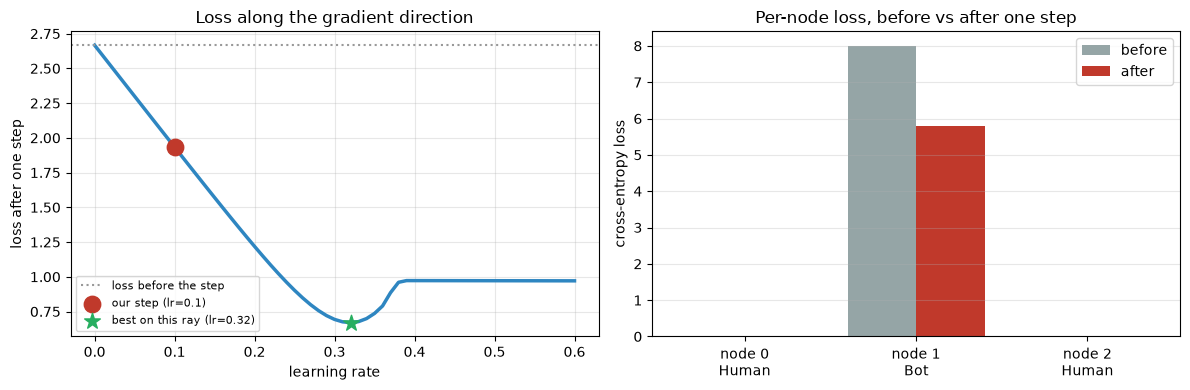

our lr=0.1 gave loss 1.9334; the best step size along this
direction was lr=0.32 giving 0.6702.
The curve is smooth and decreasing here, which is why a modest lr is safe.
Push far enough right and it would turn back up -- that is overshooting.


In [12]:
# --- Was 0.1 a good step size? Sweep it. -----------------------------------
lrs = np.linspace(0.0, 0.6, 61)
losses = []
for _lr in lrs:
    with torch.no_grad():
        W_t = W.data - _lr * W.grad
        losses.append(Fnn.cross_entropy(torch.relu(X_smooth @ W_t) @ U.data, y).item())
losses = np.array(losses)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lrs, losses, color="#2E86C1", lw=2.5)
axes[0].axhline(loss.item(), color="#999999", ls=":", lw=1.5, label="loss before the step")
axes[0].scatter([lr], [loss_2.item()], color="#C0392B", s=140, zorder=5,
                label=f"our step (lr={lr})")
axes[0].scatter([lrs[losses.argmin()]], [losses.min()], color="#27AE60", s=140,
                marker="*", zorder=5,
                label=f"best on this ray (lr={lrs[losses.argmin()]:.2f})")
axes[0].set_xlabel("learning rate"); axes[0].set_ylabel("loss after one step")
axes[0].set_title("Loss along the gradient direction")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

xb = np.arange(3)
axes[1].bar(xb - 0.2, per_node_loss.detach().numpy(), 0.4,
            label="before", color="#95A5A6")
axes[1].bar(xb + 0.2, per_node_loss_2.numpy(), 0.4, label="after", color="#C0392B")
axes[1].set_xticks(xb)
axes[1].set_xticklabels([f"node {i}\n{['Human','Bot'][y[i]]}" for i in range(3)])
axes[1].set_ylabel("cross-entropy loss")
axes[1].set_title("Per-node loss, before vs after one step")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print(f"our lr=0.1 gave loss {loss_2.item():.4f}; the best step size along this")
print(f"direction was lr={lrs[losses.argmin()]:.2f} giving {losses.min():.4f}.")
print("The curve is smooth and decreasing here, which is why a modest lr is safe.")
print("Push far enough right and it would turn back up -- that is overshooting.")

---

# What we just did

One complete training cycle, with no black boxes:

| Step | Operation | Shapes | Result |
|---|---|---|---|
| 1 | $X_{\text{smooth}} = \hat{D}^{-1}\hat{A}X$ | $(3{\times}3)(3{\times}3)(3{\times}2) \to (3{\times}2)$ | neighbourhood means |
| 2 | $H = X_{\text{smooth}}W$ | $(3{\times}2)(2{\times}2) \to (3{\times}2)$ | learned projection |
| 3 | $H_{\text{act}} = \mathrm{ReLU}(H)$ | $(3{\times}2)$ | one entry clamped |
| 4 | $Z = H_{\text{act}}U$ | $(3{\times}2)(2{\times}2) \to (3{\times}2)$ | class scores |
| 5 | $P = \mathrm{softmax}(Z)$ | $(3{\times}2)$ | rows sum to 1 |
| 6 | $\mathcal{L} = \frac1N\sum -\log p_{i,c_i}$ | scalar | **2.666865** |
| 7 | `loss.backward()` | $\nabla_W$ is $(2{\times}2)$ | verified 3 ways |
| 8 | $W \leftarrow W - \eta\nabla_W$ | $(2{\times}2)$ | **loss → 1.933422** |

## Five things the decimals revealed

1. **Aggregation inverted the signal.** The bot had the highest raw spam score
   (6) and the *lowest* smoothed one (2.33), because a degree-3 node dilutes
   itself while donating to its degree-2 neighbours. This is over-smoothing
   visible at $N=3$, and it is forced by the geometry, not by our choice of
   numbers.
2. **Separability moved, it did not vanish.** The bot is still isolable — by the
   *ratio* of spam to activity rather than by level. Aggregation changed which
   feature carries the signal.
3. **Confident errors dominate.** Node 1 contributed ~100% of the loss because
   $-\log p$ explodes as $p \to 0$. The two correct nodes were effectively
   invisible to the optimiser.
4. **ReLU blocks gradients, not just values.** The single clamped entry belonged
   to the one node that mattered, so column 1 of `W.grad` came out ~2200× smaller
   than column 0 and barely moved. Dying ReLU, in one cell.
5. **The gradient is just a measured slope.** Finite differences in float64
   reproduced autograd to ~4e-8 relative error on the two large entries. The
   two near-zero entries agreed only to ~6e-5 — and that residual sits in
   *autograd's* float32 value, not the finite difference, because
   `probs - onehot` = $1 - 0.99975$ cancels away four leading digits. Nothing
   in `backward()` is unknowable, but float32 gradients built on cancellation
   carry fewer good digits than they appear to.
6. **The mean loss trades nodes off against each other.** The step raised the
   loss on both correctly-classified humans in order to cut the bot's by 2.2.
   Optimising an average never promises that any individual improves.

## Honest scope

This is a mechanism demo. Three nodes, no held-out set, hand-picked weights, one
step — it shows *how* the arithmetic works, and nothing about whether GCNs detect
bots well. The loss dropped 27.5% in one step largely because the initial state
was so badly wrong; that rate does not continue.

Two simplifications worth naming: we updated $W$ but held the head $U$ fixed
(a real optimiser moves both simultaneously), and we used plain SGD — Adam,
which the replication actually uses, additionally tracks per-parameter running
moments, so its step is *not* simply $-\eta \nabla$.

## Where to go next

- `core-concepts.ipynb` — the same maths at 8 nodes, plus GraphSAGE and why the
  transductive/inductive distinction matters.
- `replication.ipynb` — the real pipeline: BERT text embeddings, `SAGEConv`,
  linear SVM, 5,301 labelled Cresci-15 accounts.

### Exercises

1. Set $W_{[1,1]} = 1.5$ so node 1's pre-activation turns positive. Does column
   1 of `W.grad` come alive?
2. Re-run with $\eta = 2.0$. Find the point where the loss increases.
3. Move the bot to the end of the chain (make node 0 the bot). Does aggregation
   still invert the spam ordering? Why not?
4. Loop cells 2–7 fifty times, updating $U$ as well. Does the bot ever get
   classified correctly?